# 🛍️ Customer Segmentation using Unsupervised Learning

## 🎯 Objective
Segment customers based on purchasing behavior using clustering techniques to derive actionable business insights.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [2]:
df=pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Text(0.5, 1.0, 'Spending Score')

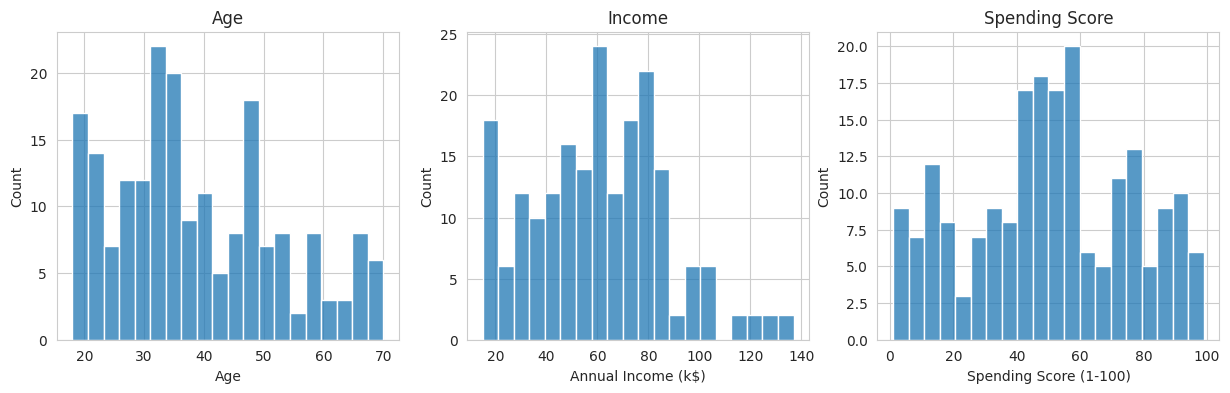

In [5]:
fig, ax=plt.subplots(1,3,figsize=(15,4))

sns.histplot(df['Age'],bins=20,ax=ax[0])
ax[0].set_title('Age')

sns.histplot(df['Annual Income (k$)'],bins=20,ax=ax[1])
ax[1].set_title('Income')

sns.histplot(df['Spending Score (1-100)'],bins=20,ax=ax[2])
ax[2].set_title('Spending Score')

- Customers show variation in income and spending
- Clustering is suitable for segmentation

In [6]:
from sklearn.preprocessing import StandardScaler

x=df[['Annual Income (k$)','Spending Score (1-100)']]
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

- Scaling is critical for distance-based algorithms

Text(0.5, 1.0, 'Elbow Method')

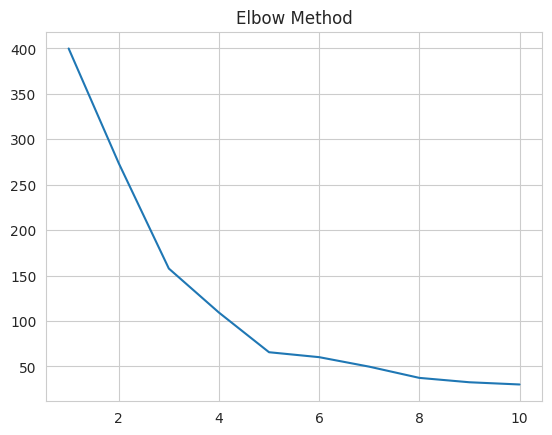

In [7]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

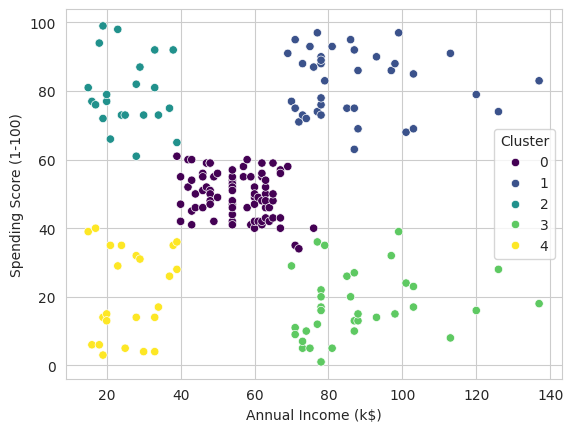

In [9]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)

- Distinct customer segments are visible

In [10]:
from sklearn.cluster import DBSCAN

db=DBSCAN(eps=0.5,min_samples=5)
df['DBSCAN_Cluster']=db.fit_predict(x_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

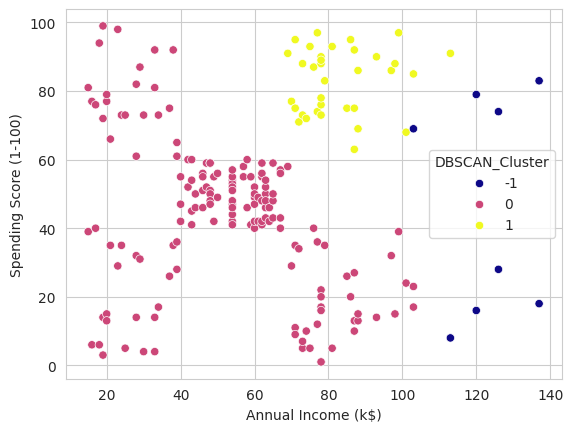

In [11]:
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['DBSCAN_Cluster'],
    palette='plasma'
)

- DBSCAN detects noise points
- Useful for irregular cluster shapes

In [12]:
from sklearn.metrics import silhouette_score

score=silhouette_score(x_scaled,df['Cluster'])
print('Silhouette Score:',score)

Silhouette Score: 0.5546571631111091


## 📈 Evaluation

The model achieved a Silhouette Score of 0.55, indicating good cluster separation.

This confirms that customer groups are meaningfully segmented and suitable for business decision-making.

In [13]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster
Cluster,,,,,
0,86.320988,42.716049,55.296296,49.518519,0.000000
1,162.000000,32.692308,86.538462,82.128205,0.794872
2,23.090909,25.272727,25.727273,79.363636,0.000000
3,164.371429,41.114286,88.200000,17.114286,-0.114286
4,23.000000,45.217391,26.304348,20.913043,0.000000


- High Income + High Spending → Premium customers  
- High Income + Low Spending → Target for marketing  
- Low Income + High Spending → Impulsive buyers  
- Low Income + Low Spending → Budget segment  

Text(0.5, 1.0, 'Final Customer Segmentation')

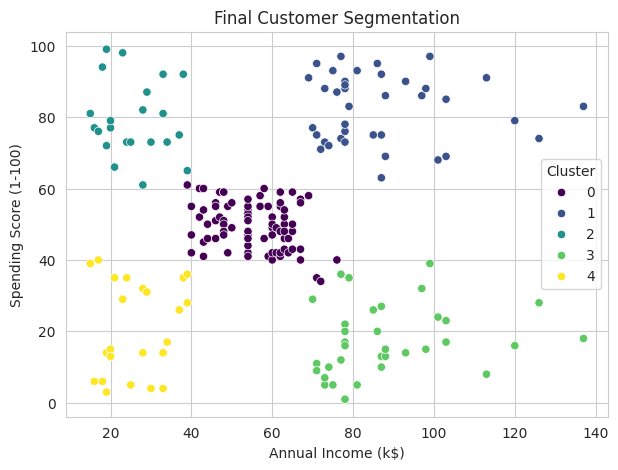

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title('Final Customer Segmentation')

- KMeans provides clear segmentation
- DBSCAN adds robustness by detecting noise
- Segmentation enables targeted business strategies